In [2]:
# 버전 체크
import sys
from packaging import version
import sklearn

assert sys.version_info >= (3, 7), f"Python 3.7+ 필요 (현재: {sys.version})"
assert version.parse(sklearn.__version__) >= version.parse("1.0.1"), \
    f"scikit-learn 1.0.1+ 필요 (현재: {sklearn.__version__})"

print(f"Python: {sys.version.split()[0]}")
print(f"scikit-learn: {sklearn.__version__}")

Python: 3.13.5
scikit-learn: 1.7.1


# SVM

1️⃣ MNIST 불러오기

In [3]:
from sklearn.datasets import fetch_openml
import numpy as np

mnist = fetch_openml('mnist_784', version=1, as_frame=False)
X = mnist.data.astype(np.float32) / 255.0  # 0~1 스케일
y = mnist.target.astype(np.int64)

print("X shape:", X.shape, "\ny shape:", y.shape)
print("클래스:", np.unique(y))

X shape: (70000, 784) 
y shape: (70000,)
클래스: [0 1 2 3 4 5 6 7 8 9]


2️⃣ 교차검증

In [4]:
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv

StratifiedKFold(n_splits=5, random_state=42, shuffle=True)

3️⃣ SVM 파이프라인, 파라미터 정의

In [5]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
import pandas as pd

svm_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LinearSVC(dual=False, tol=1e-3, max_iter=5000, random_state=42))
])


4️⃣ RandomizedSearchCV 실행(최적 모델 탐색)

In [6]:
# === SVM RandomizedSearchCV로 교체 ===
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform
import pandas as pd

# C를 로그스케일에서 무작위 샘플링 (대략 0.01 ~ 100)
param_dist = {
    "clf__C": loguniform(1e-2, 1e2)
}

svm_rs = RandomizedSearchCV(
    estimator=svm_pipe,
    param_distributions=param_dist,
    n_iter=20,               # 시도 횟수(10~30 권장; 늘리면 정밀↑, 시간↑)
    cv=cv,                   # 기존 5-fold 유지
    scoring="accuracy",
    n_jobs=2,                # Windows 안정 설정
    pre_dispatch="2*n_jobs",
    random_state=42,
    verbose=1,
    refit=True
)

print("🚀 SVM RandomizedSearch 시작...")
svm_rs.fit(X, y)
print("✅ 완료!")

print("\n📊 Best CV acc:", svm_rs.best_score_)
print("📌 Best params:", svm_rs.best_params_)

cvres = (
    pd.DataFrame(svm_rs.cv_results_)
      .sort_values("mean_test_score", ascending=False)
      .loc[:, ["mean_test_score", "std_test_score", "param_clf__C"]]
      .head(10)
)
display(cvres)

# 최적 파이프라인
best_svm = svm_rs.best_estimator_


🚀 SVM RandomizedSearch 시작...
Fitting 5 folds for each of 20 candidates, totalling 100 fits
✅ 완료!

📊 Best CV acc: 0.9119285714285713
📌 Best params: {'clf__C': np.float64(0.05415244119402541)}


,mean_test_score,std_test_score,param_clf__C
15,0.911929,0.002351,0.054152
4,0.911843,0.002383,0.042080
13,0.911843,0.002348,0.070690
5,0.911800,0.002298,0.042071
14,0.911771,0.002233,0.053370
12,0.911771,0.002028,21.368329
19,0.911729,0.002145,0.146190
16,0.911671,0.002266,0.164804
17,0.911671,0.002095,1.256104
9,0.911671,0.002089,6.796578


5️⃣️ 최적 모델 기반 교차검증 예측 → 성능 평가

In [7]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import classification_report, accuracy_score

# ✅ 최적 모델 추출
best_svm = svm_rs.best_estimator_

print("\n🔍 최적 SVM 모델로 교차검증 예측 중...")
y_pred_svm = cross_val_predict(best_svm, X, y, cv=cv, n_jobs=2)

# ✅ 성능 평가
print("\n📈 최종 CV Accuracy (SVM):", accuracy_score(y, y_pred_svm))
print("\n📄 Classification Report (SVM):")
print(classification_report(y, y_pred_svm, digits=4, zero_division=0))


🔍 최적 SVM 모델로 교차검증 예측 중...

📈 최종 CV Accuracy (SVM): 0.9119285714285714

📄 Classification Report (SVM):
              precision    recall  f1-score   support

           0     0.9482    0.9723    0.9601      6903
           1     0.9425    0.9741    0.9580      7877
           2     0.9078    0.8857    0.8966      6990
           3     0.8959    0.8829    0.8893      7141
           4     0.9088    0.9260    0.9173      6824
           5     0.8786    0.8620    0.8702      6313
           6     0.9372    0.9508    0.9440      6876
           7     0.9238    0.9264    0.9251      7293
           8     0.8810    0.8484    0.8644      6825
           9     0.8836    0.8780    0.8808      6958

    accuracy                         0.9119     70000
   macro avg     0.9107    0.9107    0.9106     70000
weighted avg     0.9115    0.9119    0.9116     70000



6️⃣ 혼동행렬(Confusion Matrix)

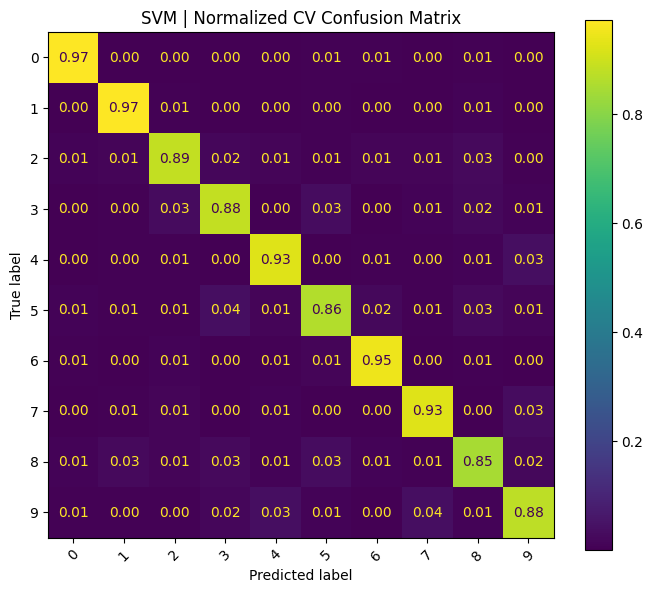

In [8]:
# 정규화 혼동행렬
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

cm = confusion_matrix(y, y_pred_svm, labels=np.arange(10))
cm_norm = cm.astype(np.float32) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(7,6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=np.arange(10))
disp.plot(values_format=".2f", cmap="viridis", ax=ax, colorbar=True)  

ax.set_title("SVM | Normalized CV Confusion Matrix")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


KeysView(NpzFile 'handmade_merged.npz' with keys: X, y)
🧪 Handmade Test (SVM) | Accuracy: 0.101875

📄 Classification Report (SVM, Handmade Test)
              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000       160
           1     0.0889    0.0250    0.0390       160
           2     0.0000    0.0000    0.0000       160
           3     0.0000    0.0000    0.0000       160
           4     0.0000    0.0000    0.0000       160
           5     0.1023    0.9938    0.1854       160
           6     0.0000    0.0000    0.0000       160
           7     0.0000    0.0000    0.0000       160
           8     0.0000    0.0000    0.0000       160
           9     0.0000    0.0000    0.0000       160

    accuracy                         0.1019      1600
   macro avg     0.0191    0.1019    0.0224      1600
weighted avg     0.0191    0.1019    0.0224      1600



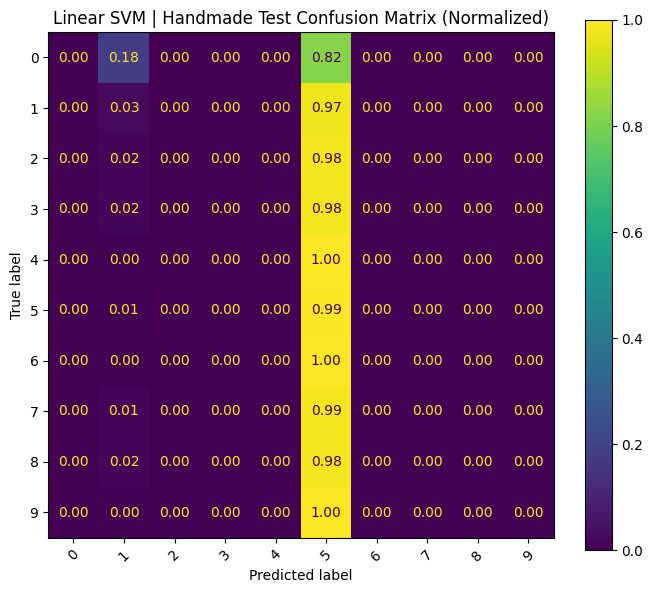

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# 1) handmade npz 로드
d = np.load("handmade_merged.npz")
print(d.keys())
Xh = d["X"]   # (N, 28, 28) 또는 (N, 784)
yh = d["y"]   # (N,)

# 2) Xh 모양/스케일 정리
# (N,28,28) -> (N,784)
if Xh.ndim == 3 and Xh.shape[1:] == (28, 28):
    Xh = Xh.reshape(len(Xh), -1).astype(np.float32)
else:
    Xh = Xh.astype(np.float32)

# MNIST 학습 때 X를 0~1로 나눴다면 handmade도 동일하게 맞추기
Xh = Xh / 255.0

# 3) 최적 SVM 파이프라인으로 예측
# best_svm 이 없으면 아래 주석 해제해서 가져오기
# best_svm = svm_rs.best_estimator_  # 또는 svm_gs.best_estimator_

y_pred_svm_h = best_svm.predict(Xh)

# 4) 성능 지표
print("🧪 Handmade Test (SVM) | Accuracy:", accuracy_score(yh, y_pred_svm_h))
print("\n📄 Classification Report (SVM, Handmade Test)")
print(classification_report(yh, y_pred_svm_h, digits=4, zero_division=0))

# 5) 정규화 혼동행렬
labels = np.unique(yh)  # 보통 0~9
cm = confusion_matrix(yh, y_pred_svm_h, labels=labels)
cm_norm = cm / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(7,6))
ConfusionMatrixDisplay(cm_norm, display_labels=labels).plot(
    values_format="0.2f", cmap="viridis", ax=ax, colorbar=True
)
ax.set_title("Linear SVM | Handmade Test Confusion Matrix (Normalized)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [10]:
from joblib import dump
import json

# ✅ 저장할 파일명 (버전 넘버 방식)
model_path = "final_svm_v1.joblib"
meta_path  = "final_svm_v1.json"

# 1️⃣ 모델 저장 (best_svm은 GridSearch 또는 RandomizedSearch 후 얻은 최적 모델)
dump(best_svm, model_path)
print(f"💾 모델 저장 완료: {model_path}")

# 2️⃣ 메타 정보(하이퍼파라미터, CV 성능 등) 저장
meta = {
    "best_params": svm_rs.best_params_ if 'svm_rs' in locals() else svm_gs.best_params_,
    "best_cv_accuracy": float(svm_rs.best_score_ if 'svm_rs' in locals() else svm_gs.best_score_),
    "cv_n_splits": getattr(cv, "n_splits", None),
    "model_class": type(best_svm).__name__,
    "version": "v1"
}

with open(meta_path, "w", encoding="utf-8") as f:
    json.dump(meta, f, ensure_ascii=False, indent=2)

print(f"📝 메타 데이터 저장 완료: {meta_path}")


💾 모델 저장 완료: final_svm_v1.joblib
📝 메타 데이터 저장 완료: final_svm_v1.json


In [15]:
from joblib import load
import json

# 1️⃣ 모델 불러오기
model_path = "final_svm_v1.joblib"
meta_path  = "final_svm_v1.json"

best_svm_loaded = load(model_path)
print(f"✅ 모델 로드 완료: {model_path}")

# 2️⃣ 메타 정보 불러오기 (선택)
with open(meta_path, "r", encoding="utf-8") as f:
    meta = json.load(f)

print("📄 모델 메타 정보:")
for k, v in meta.items():
    print(f"  {k}: {v}")


✅ 모델 로드 완료: final_svm_v1.joblib
📄 모델 메타 정보:
  best_params: {'clf__C': 0.05415244119402541}
  best_cv_accuracy: 0.9119285714285713
  cv_n_splits: 5
  model_class: Pipeline
  version: v1


In [19]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# 1) handmade npz 로드 (파일명/경로는 상황에 맞게)
d = np.load("handmade_merged.npz")
print(d.keys())
Xh = d["X"]   # (N, 28, 28) 또는 (N, 784)
yh = d["y"] # (N,)

# 1) Xh 모양/스케일 정리
# (N,28,28) -> (N,784)
if Xh.ndim == 3 and Xh.shape[1:] == (28, 28):
    Xh = Xh.reshape(len(Xh), -1).astype(np.float32)
else:
    Xh = Xh.astype(np.float32)


# [참고] MNIST 학습 시 X를 0~1로 스케일했다면 아래 주석 해제 (의사결정나무는 스케일 민감도 낮음)
# Xh = Xh / 255.0

model=best_svm_loaded
# 2) 최적 모델로 예측 (없으면: best_dt = dt_gs.best_estimator_)
y_pred_h = model.predict(Xh)

# 3) 성능 지표
print("🧪 Handmade Test | Accuracy:", accuracy_score(yh, y_pred_h))
print("\n📄 Classification Report (Handmade Test)")
print(classification_report(yh, y_pred_h, digits=4, zero_division=0))



KeysView(NpzFile 'handmade_merged.npz' with keys: X, y)
🧪 Handmade Test | Accuracy: 0.169375

📄 Classification Report (Handmade Test)
              precision    recall  f1-score   support

           0     0.0811    0.0187    0.0305       160
           1     0.1068    0.2250    0.1449       160
           2     0.1863    0.1187    0.1450       160
           3     0.2025    0.1000    0.1339       160
           4     0.3122    0.4313    0.3622       160
           5     0.1214    0.2875    0.1707       160
           6     0.1273    0.0875    0.1037       160
           7     0.2629    0.4125    0.3212       160
           8     0.1176    0.0125    0.0226       160
           9     0.0000    0.0000    0.0000       160

    accuracy                         0.1694      1600
   macro avg     0.1518    0.1694    0.1435      1600
weighted avg     0.1518    0.1694    0.1435      1600



keys: ['images', 'labels']
🧪 Handmade Test | Accuracy: 0.19774107983229228

📄 Classification Report (Handmade Test)
              precision    recall  f1-score   support

           0     0.2422    0.1063    0.1478      1166
           1     0.1590    0.3708    0.2226      1173
           2     0.2792    0.1763    0.2161      1180
           3     0.1832    0.2401    0.2078      1183
           4     0.2450    0.1969    0.2183      1173
           5     0.1804    0.1648    0.1723      1183
           6     0.2246    0.3541    0.2749      1169
           7     0.2142    0.2216    0.2178      1160
           8     0.1861    0.0853    0.1170      1161
           9     0.1174    0.0562    0.0760      1139

    accuracy                         0.1977     11687
   macro avg     0.2031    0.1972    0.1871     11687
weighted avg     0.2034    0.1977    0.1874     11687



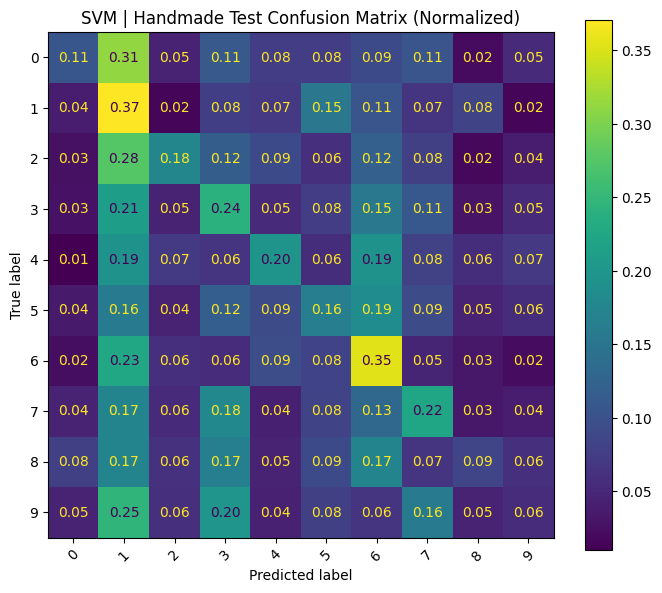

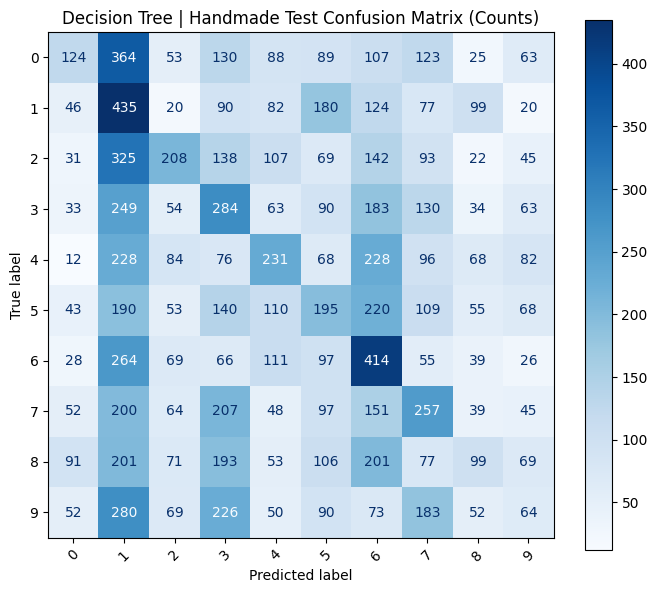

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# 1) handmade npz 로드
d = np.load("custom_MNIST2.npz", allow_pickle=True)

print("keys:", list(d.keys()))
Xh = d["images"]   # (N,28,28) 또는 (N,784)
yh = d["labels"]

# 2) 모양 정리: (N,28,28) -> (N,784)
if Xh.ndim == 3 and Xh.shape[1:] == (28, 28):
    Xh = Xh.reshape(len(Xh), -1).astype(np.float32)
else:
    Xh = Xh.astype(np.float32)

# 4) 레이블 타입 정리
yh = yh.astype(int)

# 5) 모델 선택 (하나만 활성화)
model=best_svm_loaded

# 6) 예측 & 성능 지표
y_pred_h = model.predict(Xh)

print("🧪 Handmade Test | Accuracy:", accuracy_score(yh, y_pred_h))
print("\n📄 Classification Report (Handmade Test)")
print(classification_report(yh, y_pred_h, digits=4, zero_division=0))

# 7) 혼동행렬 (정규화/카운트 둘 다 보고 싶을 때)
labels = np.arange(10)  # handmade 라벨이 0~9라면 고정하는 게 비교에 안전

# (a) 정규화
cm = confusion_matrix(yh, y_pred_h, labels=labels)
cm_norm = cm / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(7,6))
ConfusionMatrixDisplay(cm_norm, display_labels=labels).plot(
    values_format=".2f", cmap="viridis", ax=ax, colorbar=True
)
ax.set_title("SVM | Handmade Test Confusion Matrix (Normalized)")
plt.xticks(rotation=45); plt.tight_layout(); plt.show()

# (b) 원시 카운트(선택)
fig, ax = plt.subplots(figsize=(7,6))
ConfusionMatrixDisplay(cm, display_labels=labels).plot(
    values_format="d", cmap="Blues", ax=ax, colorbar=True
)
ax.set_title("Decision Tree | Handmade Test Confusion Matrix (Counts)")
plt.xticks(rotation=45); plt.tight_layout(); plt.show()
